# Phần 4: Logistic Regression (Hồi quy Logistic)

## A. Đọc hiểu (Lý thuyết cơ bản)

### Mục đích
Giải quyết các bài toán phân loại nhị phân có đầu ra là 0 hoặc 1 (ví dụ: dự đoán hồ sơ có được cho vay hay không dựa vào mức lương và năm kinh nghiệm, mail có phải là spam không, khối u là lành hay ác tính).

### Đầu ra là Xác suất
Khác với Linear Regression, Logistic Regression không trả về một con số tuyến tính mà trả về xác suất (từ 0 đến 1) của một sự kiện xảy ra.

### Hàm Sigmoid (Activation Function)
Để đưa giá trị tính toán được từ phương trình đường thẳng ($z = w_0 + w_1 x_1 + w_2 x_2$) về khoảng [0,1], mô hình đưa z qua hàm Sigmoid:  
$\sigma(z) = \frac{1}{1 + e^{-z}}$.

### Hàm mất mát (Loss function)
Do tính chất của xác suất, ta sử dụng hàm Binary Cross-Entropy thay cho MSE:  
$L = -(y_i \cdot \log(\hat{y}_i) + (1 - y_i) \cdot \log(1 - \hat{y}_i))$.  
Hàm này trừng phạt rất nặng (tạo ra loss lớn) khi mô hình tự tin dự đoán sai.

### Đường phân chia (Decision Boundary)
Nếu ta lấy mốc xác suất 50% ($\hat{y} \geq 0.5$) để quyết định class, thì đường thẳng $w_0 + w_1 x_1 + w_2 x_2 = 0$ chính là đường ranh giới phân chia hai nhãn dữ liệu.

## B. Implement (Code Python bằng Numpy)
Các bước huấn luyện bằng ma trận và Gradient Descent (sử dụng Chain Rule để tính đạo hàm).

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
# 1. Định nghĩa hàm Sigmoid
def sigmoid(x):
    x = np.clip(x, -500, 500)  # Tránh overflow trong np.exp
    return 1 / (1 + np.exp(-x))

In [15]:
# 2. Đọc dữ liệu
# Giả sử file 'dataset.csv' có 3 cột: lương, kinh nghiệm, nhãn (0/1)
# Nếu không có file, tạo dữ liệu mẫu
try:
    data = pd.read_csv('dataset.csv').values
except FileNotFoundError:
    # Tạo dữ liệu mẫu: 2 features (lương, kinh nghiệm), nhãn 0/1
    np.random.seed(42)
    N = 200
    x1 = np.random.normal(50, 10, N)  # Lương trung bình
    x2 = np.random.normal(5, 2, N)    # Kinh nghiệm
    # Nhãn: 1 nếu lương > 55 và kinh nghiệm > 4, else 0
    y_vals = ((x1 > 55) & (x2 > 4)).astype(int)
    data = np.column_stack((x1, x2, y_vals))

N, d = data.shape
x = data[:, 0:d-1].reshape(-1, d-1)  # Lương và kinh nghiệm
y = data[:, d-1].reshape(-1, 1)      # Nhãn (0 hoặc 1)

In [16]:
# 3. Thêm cột 1 vào x để tính hệ số bias w0
x = np.hstack((np.ones((N, 1)), x))

In [17]:
# 4. Khởi tạo tham số w0, w1, w2
w = np.array([0., 0.1, 0.1]).reshape(-1, 1)

In [18]:
# 5. Thiết lập tham số cho Gradient Descent
numOfIteration = 1000
cost = np.zeros((numOfIteration, 1))
learning_rate = 0.01

In [19]:
# 6. Huấn luyện mô hình (Training)
for i in range(1, numOfIteration):
    # Tính giá trị dự đoán qua hàm sigmoid
    y_predict = sigmoid(np.dot(x, w))
    
    # Tính Binary Cross-Entropy Loss function
    cost[i] = -np.sum(np.multiply(y, np.log(y_predict + 1e-8)) + \
                      np.multiply(1 - y, np.log(1 - y_predict + 1e-8)))  # +1e-8 tránh log(0)
    
    # Cập nhật trọng số w bằng Gradient Descent
    w = w - learning_rate * np.dot(x.T, y_predict - y)

In [20]:
# Dự đoán cho một ví dụ mới (lương=60, kinh nghiệm=6)
x_new = np.array([1, 60, 6]).reshape(1, -1)  # Thêm bias
prob = sigmoid(np.dot(x_new, w))
prediction = 1 if prob >= 0.5 else 0
print(f'Xác suất cho vay: {prob[0][0]:.4f}, Dự đoán: {prediction} (1=cho vay, 0=không)')

Xác suất cho vay: 1.0000, Dự đoán: 1 (1=cho vay, 0=không)


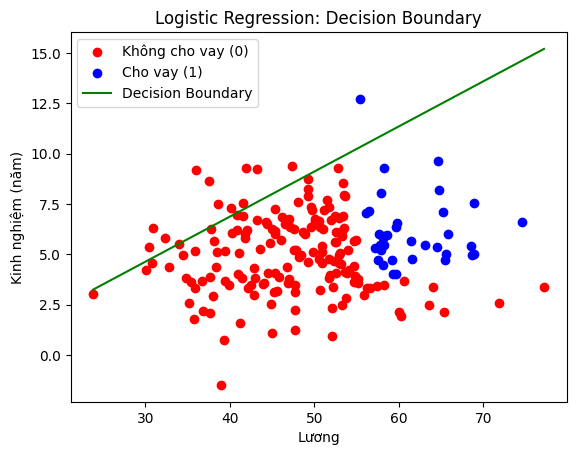

In [21]:
# Vẽ biểu đồ dữ liệu và đường phân chia
plt.scatter(data[y.flatten() == 0, 0], data[y.flatten() == 0, 1], color='red', label='Không cho vay (0)')
plt.scatter(data[y.flatten() == 1, 0], data[y.flatten() == 1, 1], color='blue', label='Cho vay (1)')

# Vẽ decision boundary: w0 + w1*x1 + w2*x2 = 0 => x2 = -(w0 + w1*x1)/w2
x1_vals = np.linspace(data[:, 0].min(), data[:, 0].max(), 100)
x2_vals = -(w[0] + w[1] * x1_vals) / w[2]
plt.plot(x1_vals, x2_vals, color='green', label='Decision Boundary')

plt.xlabel('Lương')
plt.ylabel('Kinh nghiệm (năm)')
plt.legend()
plt.title('Logistic Regression: Decision Boundary')
plt.show()

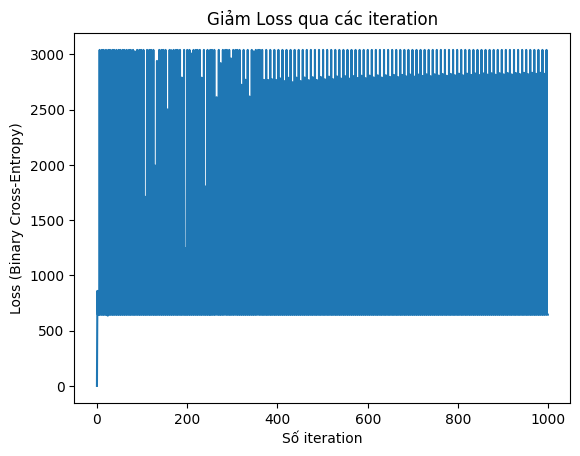

In [22]:
# Vẽ biểu đồ Loss function theo số iteration
plt.plot(range(numOfIteration), cost)
plt.xlabel('Số iteration')
plt.ylabel('Loss (Binary Cross-Entropy)')
plt.title('Giảm Loss qua các iteration')
plt.show()

### Ghi chú: Cách implement ngắn gọn hơn bằng thư viện sklearn.linear_model.LogisticRegression

In [23]:
from sklearn.linear_model import LogisticRegression

# Sử dụng sklearn
model = LogisticRegression()
model.fit(data[:, 0:2], data[:, 2])  # x là lương và kinh nghiệm, y là nhãn

# Dự đoán
prob_sklearn = model.predict_proba([[60, 6]])[0][1]  # Xác suất class 1
pred_sklearn = model.predict([[60, 6]])[0]
print(f'Xác suất cho vay (sklearn): {prob_sklearn:.4f}, Dự đoán: {pred_sklearn}')
print('w (coefficients): ', model.coef_[0])
print('w0 (intercept): ', model.intercept_[0])

Xác suất cho vay (sklearn): 0.7062, Dự đoán: 1.0
w (coefficients):  [0.42599913 0.78077934]
w0 (intercept):  -29.367797891074847
